In [1]:
# Import the pandas library for data manipulation
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dataset=pd.read_csv("/content/drive/MyDrive/HopeAI/ml_regression_dataset/insurance_pre.csv")
# Display the loaded dataset
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [3]:
dataset=pd.get_dummies(dataset,dtype=int,drop_first=True)
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes'], dtype='object')

In [4]:
independent= dataset[['age', 'bmi', 'children', 'sex_male','smoker_yes']]
independent

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [5]:
dependent= dataset[["charges"]]
dependent

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(independent,dependent,test_size=0.30,random_state=0)

In [7]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(criterion='squared_error',splitter='best',max_depth=3)
regressor=regressor.fit(X_train,y_train)

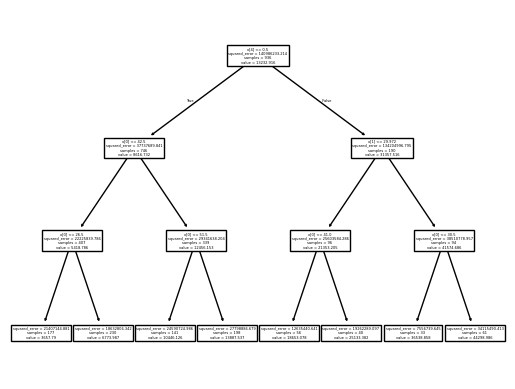

In [8]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [9]:
y_pred=regressor.predict(X_test)

In [10]:
from sklearn.metrics import r2_score
r_score= r2_score(y_test,y_pred)
r_score

0.8751026719462079

In [11]:
import pickle
filename="Finalized_AssignmentModel_DecisionTree_.sav"
pickle.dump(regressor,open(filename,'wb'))

In [12]:
loaded_model=pickle.load(open("Finalized_AssignmentModel_DecisionTree_.sav",'rb'))
result=loaded_model.predict([[18,33.77,1,1,0]])
result

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([3657.79000051])